#### Noise sweep

In [13]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

project_root = Path.cwd().parents[2]
sys.path.insert(0, str(project_root))

torch.set_default_dtype(torch.float64) 

# Functions needed for data generation
from scripts.shape_uncertainty.simulated_data.data_generator import WilkersonDGP
from scripts.shape_uncertainty.simulated_data.data_generator import generate_simulated_dataset
from scripts.shape_uncertainty.spline_basis.bspline_basis import build_knot_dictionary

# Functions needed to run MeanOnlyModel
from scripts.shape_uncertainty.model.model import MeanOnlyModel
from scripts.shape_uncertainty.model.model_training import Tuner
from scripts.shape_uncertainty.experiments.utilities import save_run, load_run

# Functions needed for shape extraction
from scripts.shape_uncertainty.model.model_inference import InferenceEngine
from scripts.shape_uncertainty.model.model_evaluation import ModelEvaluator
from scripts.shape_uncertainty.simulated_data.shape_ground_truth import get_analytic_shape_summary
from scripts.shape_uncertainty.shape_extraction.shape_distance import (
    exact_shape_sequence_match, shape_summary_distance,
    mean_shape_sequence_match, mean_shape_summary_distance,
)

# Helpers needed for plotting
from scripts.shape_uncertainty.experiments.plot_helpers import plot_individual_diagnostic

In [14]:
# Data-generating process
T = 1.0
ALPHA_G, ALPHA_D = 0.0, 0.0 # 0 = no unobserved heterogeneity
HYPERPARAMS = {"g0": 2.0, "d0": 180.0, "rho0": 10.0,
               "alpha_g": ALPHA_G, "alpha_d": ALPHA_D}

# Observation design 
NR_OBS = 20 # observations per individua
REGULAR = True
SEED = 42

# Spline basis
NR_INTERIOR_KNOTS = 5 # B = K + 4 = 9, matches TimeView

# Dataset
D_TRAIN, D_VAL, D_TEST = 2000, 1000, 1000
D_TOTAL = D_TRAIN + D_VAL + D_TEST

# Pruned shape extraction
UPSILON_1_REL, UPSILON_2_REL = 0.0, 0.0
ZETA_REL, UPSILON_PRUNE_REL, DO_PRUNE = 1e-6, 0.025, True

# Measurement noise sweep values
SIGMA_GRID  = [0.0, 0.01, 0.02, 0.05, 0.10]
LAMBDA_GRID = [0.0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]      # the penalty sweep, per noise level


In [15]:
# Noise sweep helpers

def make_split(sigma):
    ds = generate_simulated_dataset(dgp, D=D_TOTAL, N=NR_OBS, sigma=sigma,
                                    regular=REGULAR, seed=SEED)
    return ds.split_test_val_train(D_train=D_TRAIN, D_val=D_VAL, D_test=D_TEST)

def pruned_score(model, normaliser, test):
    engine = InferenceEngine()
    engine.populate_attributes(
        model=model, normaliser=normaliser,
        basis_functions=knot_objects["basis_functions"],
        C=knot_objects["C"], breakpoints=knot_objects["breakpoints"],
        zeta_rel=ZETA_REL, upsilon_rel_1=UPSILON_1_REL, upsilon_rel_2=UPSILON_2_REL,
        upsilon_rel_prune=UPSILON_PRUNE_REL, do_prune=True,
    )
    predicted = [engine.predict_mean_shape_summary(x) for x in test.individual_covariates()]
    true = get_analytic_shape_summary(test, UPSILON_1_REL, UPSILON_2_REL, UPSILON_PRUNE_REL, True)
    return (mean_shape_sequence_match(predicted, true),
            mean_shape_summary_distance(predicted, true, test.T))


In [16]:
knot_objects = build_knot_dictionary(nr_interior_knots=NR_INTERIOR_KNOTS, T=T)
dgp = WilkersonDGP(T=T, hyperparams=HYPERPARAMS)

In [5]:
# Do an Optuna search once on the mid-noise level architecture
# and then freeze the architecture

test0, val0, train0 = make_split(sigma=0.02)   # a mid noise level
search_tuner = Tuner(
    train_dataset=train0, 
    val_dataset=val0,
    basis_functions=knot_objects["basis_functions"], 
    Omega=knot_objects["Omega"],
    nr_basis=knot_objects["nr_basis"], 
    lambda_mean=0.0, # no wiggle penalty 
    lambda_re=0.0,
    nr_epochs=200, 
    patience=10, 
    model_cls=MeanOnlyModel, 
    model_kwargs={},
)
fixed_params = search_tuner.run(nr_trials=100)["best_params"]

[I 2026-07-22 04:01:20,690] A new study created in memory with name: no-name-a1cf63a7-8b8c-4c0f-bfcf-05380f7aec08
[I 2026-07-22 04:01:29,986] Trial 0 finished with value: 0.6191950567044071 and parameters: {'hidden_0': 79, 'hidden_1': 118, 'hidden_2': 18, 'activation': 'selu', 'dropout': 0.46867196980142856, 'lr': 0.00024988736070296203, 'batch_size': 128, 'weight_decay': 0.001996135458064751}. Best is trial 0 with value: 0.6191950567044071.
[I 2026-07-22 04:01:32,545] Trial 1 finished with value: 0.5838697925721522 and parameters: {'hidden_0': 107, 'hidden_1': 70, 'hidden_2': 43, 'activation': 'relu', 'dropout': 0.16249880129346178, 'lr': 0.0014129215369290023, 'batch_size': 128, 'weight_decay': 0.00014955284813362925}. Best is trial 1 with value: 0.5838697925721522.
[I 2026-07-22 04:01:33,922] Trial 2 finished with value: 0.5897145636713963 and parameters: {'hidden_0': 111, 'hidden_1': 58, 'hidden_2': 116, 'activation': 'selu', 'dropout': 0.16854899592927663, 'lr': 0.0154177206332275

In [17]:
# Do the 2-D sweep at the frozen architecture 
rows = []
for sigma in SIGMA_GRID:
    test_s, val_s, train_s = make_split(sigma)
    for lam in LAMBDA_GRID:
        tuner = Tuner(
            train_dataset=train_s, 
            val_dataset=val_s,
            basis_functions=knot_objects["basis_functions"], 
            Omega=knot_objects["Omega"],
            nr_basis=knot_objects["nr_basis"], 
            lambda_mean=lam, 
            lambda_re=0.0,
            nr_epochs=200, 
            patience=10, 
            model_cls=MeanOnlyModel, 
            model_kwargs={},
        )
        res = tuner.train_fixed_configuration(fixed_params)
        acc, dist = pruned_score(res["model"], res["normaliser"], test_s)
        rows.append({"sigma": sigma, "lambda": lam, "accuracy": acc, "distance": dist})
        print(f"sigma={sigma:<5} lambda={lam:<7} acc={acc:.2f} dist={dist:.3f}")

df_noise = pd.DataFrame(rows)

sigma=0.0   lambda=0.0     acc=0.72 dist=0.044
sigma=0.0   lambda=1e-05   acc=0.63 dist=0.059
sigma=0.0   lambda=0.0001  acc=0.81 dist=0.039
sigma=0.0   lambda=0.001   acc=0.89 dist=0.022
sigma=0.0   lambda=0.01    acc=0.67 dist=0.073
sigma=0.0   lambda=0.1     acc=0.14 dist=0.215
sigma=0.0   lambda=1.0     acc=0.00 dist=0.601
sigma=0.01  lambda=0.0     acc=0.64 dist=0.053
sigma=0.01  lambda=1e-05   acc=0.81 dist=0.030
sigma=0.01  lambda=0.0001  acc=0.86 dist=0.022
sigma=0.01  lambda=0.001   acc=0.86 dist=0.025
sigma=0.01  lambda=0.01    acc=0.79 dist=0.044
sigma=0.01  lambda=0.1     acc=0.06 dist=0.222
sigma=0.01  lambda=1.0     acc=0.01 dist=0.594
sigma=0.02  lambda=0.0     acc=0.65 dist=0.055
sigma=0.02  lambda=1e-05   acc=0.78 dist=0.035
sigma=0.02  lambda=0.0001  acc=0.88 dist=0.023
sigma=0.02  lambda=0.001   acc=0.91 dist=0.020
sigma=0.02  lambda=0.01    acc=0.76 dist=0.056
sigma=0.02  lambda=0.1     acc=0.04 dist=0.223
sigma=0.02  lambda=1.0     acc=0.00 dist=0.607
sigma=0.05  l

lambda,0.00000,0.00001,0.00010,0.00100,0.01000,0.10000,1.00000
sigma,,,,,,,
0.00,0.724,0.632,0.808,0.892,0.667,0.141,0.000
0.01,0.641,0.809,0.862,0.864,0.792,0.062,0.005
0.02,0.651,0.780,0.881,0.908,0.756,0.035,0.000
0.05,0.778,0.836,0.900,0.835,0.764,0.035,0.009
0.10,0.574,0.665,0.898,0.827,0.781,0.087,0.015


\begin{tabular}{lrrrrrrr}
\toprule
lambda & 0.000000 & 0.000010 & 0.000100 & 0.001000 & 0.010000 & 0.100000 & 1.000000 \\
sigma &  &  &  &  &  &  &  \\
\midrule
0.000000 & 0.724 & 0.632 & 0.808 & 0.892 & 0.667 & 0.141 & 0.000 \\
0.010000 & 0.641 & 0.809 & 0.862 & 0.864 & 0.792 & 0.062 & 0.005 \\
0.020000 & 0.651 & 0.780 & 0.881 & 0.908 & 0.756 & 0.035 & 0.000 \\
0.050000 & 0.778 & 0.836 & 0.900 & 0.835 & 0.764 & 0.035 & 0.009 \\
0.100000 & 0.574 & 0.665 & 0.898 & 0.827 & 0.781 & 0.087 & 0.015 \\
\bottomrule
\end{tabular}



lambda,0.00000,0.00001,0.00010,0.00100,0.01000,0.10000,1.00000
sigma,,,,,,,
0.00,0.044176,0.059286,0.039162,0.021992,0.072725,0.214920,0.601260
0.01,0.053291,0.029966,0.022112,0.025016,0.044126,0.221873,0.593760
0.02,0.055484,0.034911,0.023329,0.019830,0.056134,0.223482,0.606760
0.05,0.038533,0.027518,0.022009,0.034527,0.052455,0.217195,0.597927
0.10,0.058512,0.055668,0.020042,0.028895,0.047991,0.210572,0.563134


\begin{tabular}{lrrrrrrr}
\toprule
lambda & 0.000000 & 0.000010 & 0.000100 & 0.001000 & 0.010000 & 0.100000 & 1.000000 \\
sigma &  &  &  &  &  &  &  \\
\midrule
0.000000 & 0.044 & 0.059 & 0.039 & 0.022 & 0.073 & 0.215 & 0.601 \\
0.010000 & 0.053 & 0.030 & 0.022 & 0.025 & 0.044 & 0.222 & 0.594 \\
0.020000 & 0.055 & 0.035 & 0.023 & 0.020 & 0.056 & 0.223 & 0.607 \\
0.050000 & 0.039 & 0.028 & 0.022 & 0.035 & 0.052 & 0.217 & 0.598 \\
0.100000 & 0.059 & 0.056 & 0.020 & 0.029 & 0.048 & 0.211 & 0.563 \\
\bottomrule
\end{tabular}



,sigma,lambda,accuracy
3,0.00,0.0010,0.892
10,0.01,0.0010,0.864
17,0.02,0.0010,0.908
23,0.05,0.0001,0.900
30,0.10,0.0001,0.898


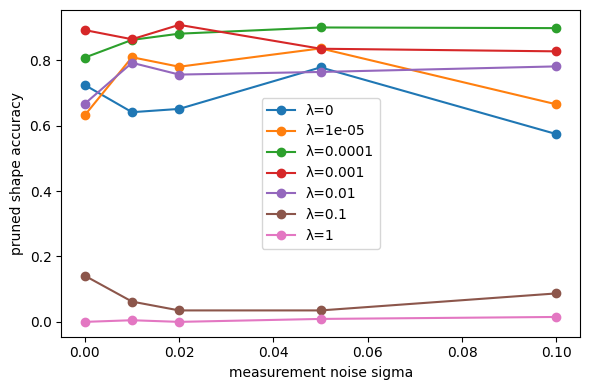

In [18]:
acc_table  = df_noise.pivot(index="sigma", columns="lambda", values="accuracy")
dist_table = df_noise.pivot(index="sigma", columns="lambda", values="distance")
display(acc_table); print(acc_table.to_latex(float_format="%.3f"))
display(dist_table); print(dist_table.to_latex(float_format="%.3f"))

# best lambda per noise level
best = df_noise.loc[df_noise.groupby("sigma")["accuracy"].idxmax(), ["sigma", "lambda", "accuracy"]]
display(best)

fig, ax = plt.subplots(figsize=(6, 4))
for lam in LAMBDA_GRID:
    sub = df_noise[df_noise["lambda"] == lam]
    ax.plot(sub["sigma"], sub["accuracy"], marker="o", label=f"λ={lam:g}")
ax.set_xlabel("measurement noise sigma"); ax.set_ylabel("pruned shape accuracy"); ax.legend()
fig.tight_layout(); plt.show()

A mild penalty helps, and helps more under noise. hypothesis that more noise means there should more penalty is not supported. best is 1e-4 at every noise level. at zero noise the penalty benefit is marginal.